# Exploratory Data Analysis (EDA).
Explore and understand the CheXpert_small and TBX11K datasets before training models.
#### Rationale:
1. Varify dataset contents, structure, and class distributions.
2. Detect potential imbalances or inconsistencies that may bias results.
3. Document image resolutions and formats to justify preprocessing choices.
4. Produce figures (class balance plots, histograms) to be discused in the report.

In [1]:
# Define dataset root paths (This notebook lives in notebooks/, so step one level up to reach the project root).
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()

# Define dataset paths relative to the project structure.
CHEXPERT_PATH = PROJECT_ROOT / "data" / "chexpert"
TBX11K_PATH   = PROJECT_ROOT / "data" / "tbx11k"

print('Project root:', PROJECT_ROOT)
print('CheXpert path exists:', CHEXPERT_PATH.exists())
print('TBX11K path exists:', TBX11K_PATH.exists())

Project root: /lab/px/msc-sept-24-ft-cohort-capstone-chrisanich
CheXpert path exists: True
TBX11K path exists: True


## 1. Dataset Overview.
Count images and inspect folder structure for CheXpert_small and TBX11K.
#### Rationale:
- Verify datasets were correctly downloaded and extracted.
- Get a first look at class balance (Normal, Pneumonia, Tuberculosis).
- Ensure consistency accross datasets before unifying them for training.
- Document findings with numbers to support the Methods section of the report.

In [2]:
# Count the number of image files in each dataset directory.
# This ensures that data is complete before further analysis.

def count_images_in_folder(path: Path, exts=(".jpg", ".jpeg", ".png")):
    """Count image files recursively in a folder."""
    return sum(1 for f in path.rglob("*") if f.suffix.lower() in exts)

chexpert_count = count_images_in_folder(CHEXPERT_PATH)
tbx11k_count = count_images_in_folder(TBX11K_PATH)

print('Image counts:')
print(f'- CheXpert_small: {chexpert_count:,} images')
print(f'- TBX11B: {tbx11k_count:,} images')

Image counts:
- CheXpert_small: 223,649 images
- TBX11B: 12,279 images


## 2. Class Distribution (TBX11K).
Load the TBX11K dataset split list (`all_trainval.txt`) and infer labels from folder and filename conventions.
#### Rationale:
- TBX11K does not provide a ready-made CSV with labels.
- Instead, image labels are encoded in file paths (`sick/`, `tb/`, or filenames ending in `_1.png` for Tuberculosis (TB), others as Normal).
- Parsing the official split list ensures reproducibility and consistency with the dataset authors' organisation.
- Class counts are essential to detect imbalance before modeling training.

In [3]:
import pandas as pd

# Define load_tbx11k_from_list() function with a type hint "-> pd.DataFrame to tell the reader
# (and tools like linters or IDEs) that it expects a Path and return a Pandas Data Frame.
def load_tbx11k_from_list(list_file: Path) -> pd.DataFrame:
    """
    Load a TBX11K split list and assign class labels.

    Parameters
    ----------
    list_file : str or Path
        Path to a text file (e.g., all_train.txt, all_val.txt, all_test.txt, all_trainval.txt).
        Each line contains a relative path to an image file.

    Returns
    -------
    pd.DataFrame
        DataFrame with two columns:
        - 'Path': relative image path
        - "Class": assigned label ('TB' or 'Normal')
    """
    with open(list_file, "r") as f:
        paths = [line.strip() for line in f if line.strip()]

    records = []
    for p in paths:
        # Label assignment is based on TBX11K naming conventions.
        if p.startswith(("sick", "tb")) or p.endswith("_1.png"):
            label = "TB"
        else:
            label = "Normal"
        records.append({"Path": p, "Class": label})

    return pd.DataFrame(records)

# Load the combined training plus validation split.
tbx11k_df = load_tbx11k_from_list(TBX11K_PATH / "lists" / "all_trainval.txt")

# Summarise class distribution.
print("TBX11K class distribution (all_trainval split):")
print(tbx11k_df['Class'].value_counts().to_string())

TBX11K class distribution (all_trainval split):
Class
TB        4798
Normal    4178


## 3. Class Distribution (CheXpert_small).
Load CheXpert_small metadata  (`train.csv`) and derive class labels for Normal vs Pneumonia.
#### Rationale:
- CheXpert provides multiple pathology labels: this study focuses on Pneumonia vs Normal.
- Sumarising class distribution ensures that the dataset is well understood before traning.
- Detecting imbalance is essential for designing evaluation estrategies.
- Provides reproducible evidence for dataset characteristics.
- CheXpert includes both frontal and lateral images; to avoid bias when combining with TBX11K (frontal only), this analysis retains only frontal views.

In [18]:
# Define load_chexpert_labels() function with a type hint "-> pd.DataFrame to tell the reader
# (and tools like linters or IDEs) that it expects a Path and return a Pandas Data Frame.
def load_chexpert_labels(csv_file: Path) -> pd.DataFrame:
    """
    Load CheXpert_small labels and reduce to Pneumonia vs Non-Pneumonia.

    Parameters
    ----------
    csv_file : Path
        Path to CheXpert's train.csv metadata file.

    Returns
    -------
    pd.DataFrame
    - 'Path': relative image path
    - 'Class': assigned label ('Pneumonia' or 'Non-Pneumonia')

    Notes
    -----
    CheXpert provides 14 pathology labels. For this project, only the 'Pneumonia'
    column is used. All images Pneumonia=1 are labelled 'Pneumonia';
    All others were grouped as Non-Pneumonia, irrespective of other co-existing pathologies.
    """
    df = pd.read_csv(csv_file)

    # Keep only image path and Pneumonia column.
    labels = df[["Path", "Pneumonia"]].copy()

    # Assign Normal vs Pneumonia class.
    labels["Class"] = labels["Pneumonia"].apply(lambda x: "Pneumonia" if x == 1 else "Non-Pneumonia")

    return labels

# Load labels from Chexpert train.csv.
chexpert_labels =load_chexpert_labels(CHEXPERT_PATH / "train.csv")

# Normalise paths by removing redundant dataset prefix.
# This is because the train.csv file includes the dataset’s original folder prefix, 
# the extracted dataset does not have that prefix in its folder structure.
chexpert_labels["Path"] = chexpert_labels["Path"].str.replace(
    "CheXpert-v1.0-small/", "", regex=False
)

# Keep only frontal images (excluse lateral views).
chexpert_labels = chexpert_labels[chexpert_labels["Path"].str.contains("frontal")]

# Summarise ditribution.
print("CheXpert_small class distribution (train split):")
print(chexpert_labels["Class"].value_counts().to_string())

CheXpert_small class distribution (train split):
Class
Non-Pneumonia    186352
Pneumonia          4675


## 4. Class Distribution (Separate Data Summaries)
Summarise the class counts for CheXpert_small and TBX11K separately.
#### Rationale:
- Provide a transparent description of how many samples exist in each dataset.
- Highlight class imbalance within each source before combining them.
- Document clearly what raw material is available for later modelling.
- Ensure reproducibility by showing dataset-specific counts before any merging.

In [20]:
# Compute class distribution for CheXpert_small (already loaded).
chexpert_counts = chexpert_labels["Class"].value_counts()

# Compute class distrubution for TBX11K (already loaded).
tbx11k_counts = tbx11k_df["Class"].value_counts()

# Combine into one summary DataFrame.
summary_df = pd.DataFrame({
    "CheXpert_small": chexpert_counts,
    "TBX11K": tbx11k_counts
}).fillna(0).astype(int) # Replace NaN with 0 to make the table clean and clear.

print("Class distributions per dataset:")
print(summary_df)

Class distributions per dataset:
               CheXpert_small  TBX11K
Class                                
Non-Pneumonia          186352       0
Normal                      0    4178
Pneumonia                4675       0
TB                          0    4798


#### Insights:
- Each dataset keeps its own classes.
- Missing classes are shown as `0` rather than `NaN`.
- It is possible to infer that **CheXpert** contributes `Pneumonia` and `Non-Pneumonia`, while **TBX11K** contributes `TB` and `Normal`.

## 5a. Class Distribution (Unified 3-Class Task).
Define that the final 3-class dataset used this project: Normal, Pneumonia, and Tuberculosis (TB).
#### Rationale:
- CheXpert_small provides `Pneumonia` cases.
- TBX11K provides `Normal` and `TB` cases.
- Combining these sources yield a clean 3-class problem without ambiguous categories.
- This step formalises the dataset definition used in all subsequent modelling experiments.

In [21]:
# Extract Pneumonia counts from CheXpert.
pneumonia_count = chexpert_labels["Class"].value_counts().get("Pneumonia", 0)

# Extract Normal and TB counts from TBX11K.
tb_counts = tbx11k_df["Class"].value_counts()
normal_count = tb_counts.get("Normal", 0)
tb_count     = tb_counts.get("TB", 0)

# Build unified 3-class summary.
unified_summary = pd.DataFrame({
    "Class": ["Normal", "Pneumonia", "TB"],
    "Dataset": ["TBX11K", "CheXpert", "TBX11K"],
    "Count" : [normal_count, pneumonia_count, tb_count]
})

print("Unified 3-class dataset summary:")
print(unified_summary.to_string(index=False))

Unified 3-class dataset summary:
    Class  Dataset  Count
   Normal   TBX11K   4178
Pneumonia CheXpert   4675
       TB   TBX11K   4798


## 5b. Class Distribution (Unified 3-Class Plot).
Visualise the unified dataset distribution across `Normal`, `Pneumonia`, and `TB`.
#### Rationale:
- Highlight the relative sizes of the three target classes.
- Provide a clear figure suitable for inclusion in the report.
- Make visible the imbalance between classes, guiding evaluation choices.
- Document the exact dataset composition used for model training.

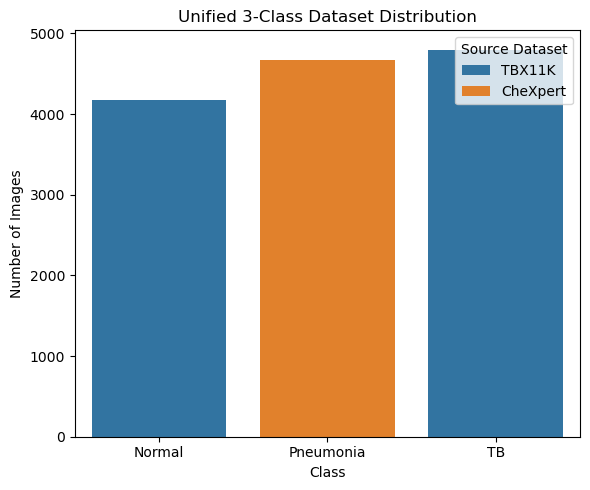

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Bar plot of the unified 3-class ditribution.
plt.figure(figsize=(6, 5))
sns.barplot(
    x=unified_summary["Class"],
    y=unified_summary["Count"],
    hue=unified_summary["Dataset"],
    dodge=False
)

plt.title("Unified 3-Class Dataset Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

# Remove legend title for cleaner look.
plt.legend(title="Source Dataset")

plt.tight_layout()
plt.show()

## 6. Image Properties.
Inspect file formats, image modes (grayscale vs RGB), and resolutions for CheXpert_small and TBX11K.  
#### Rationale:
- Create a function `scan_images` to read a sample of up to 2000 files and count formats, modes, and resolutions.  
- Apply the scan to the **CheXpert_small** train split as a whole to confirm image consistency.  
- Check each **TBX11K** subfolder (`health`, `sick`, `tb`, `extra`, `test`) separately to capture differences between groups.  
- Base preprocessing decisions (resizing to 320×320 and converting modes if needed) on the observed dataset properties.  

In [23]:
from pathlib import Path
from PIL import Image
import os
from collections import Counter

def scan_images(root_path, max_samples=2000):
    """
    Scan a folder of images and count:
      - Formats (JPEG, PNG…)
      - Modes (L=grayscale, RGB…)
      - Resolutions (width×height)
    Stops early if max_samples is reached.
    """
    # Counters for image properties.
    formats, modes, resolutions = Counter(), Counter(), Counter()
    count = 0

    # Walk through all files under the root path.
    for dirpath, _, filenames in os.walk(root_path):
        for fname in filenames:
            # Only consider image files
            if fname.lower().endswith((".png", ".jpg", ".jpeg")):
                try:
                    # Open image to check its properties
                    with Image.open(os.path.join(dirpath, fname)) as img:
                        formats[img.format] += 1
                        modes[img.mode] += 1
                        resolutions[img.size] += 1
                except:
                    continue  # skip unreadable/corrupt images.

                count += 1
                # Stop if we already inspected enough samples.
                if count >= max_samples:
                    return formats, modes, resolutions, count

    return formats, modes, resolutions, count

# ---- CheXpert ----
# Inspect up to 2000 images from CheXpert train split.
f, m, r, c = scan_images(CHEXPERT_PATH / "train", max_samples=2000)
print("\n--- CheXpert_small (train) ---")
print(f"Scanned: {c} images")
print("Formats:", dict(f.most_common(5)))
print("Modes:", dict(m.most_common(5)))
print("Resolutions:", {f"{w}×{h}": n for (w,h), n in r.most_common(5)})

# ---- TBX11K ----
# Inspect each subfolder in TBX11K (health, sick, tb, etc).
print("\n--- TBX11K (by folder) ---")
for sub in sorted((TBX11K_PATH / "imgs").iterdir()):
    if sub.is_dir():
        f, m, r, c = scan_images(sub, max_samples=2000)
        print(f"\nFolder: {sub.name} (scanned {c} images)")
        print("Formats:", dict(f.most_common(5)))
        print("Modes:", dict(m.most_common(5)))
        print("Resolutions:", {f"{w}×{h}": n for (w,h), n in r.most_common(5)})


--- CheXpert_small (train) ---
Scanned: 2000 images
Formats: {'JPEG': 2000}
Modes: {'L': 2000}
Resolutions: {'390×320': 1165, '320×320': 228, '389×320': 195, '320×390': 59, '320×369': 40}

--- TBX11K (by folder) ---

Folder: extra (scanned 576 images)
Formats: {'PNG': 472, 'JPEG': 104}
Modes: {'RGB': 576}
Resolutions: {'512×512': 576}

Folder: health (scanned 2000 images)
Formats: {'PNG': 2000}
Modes: {'RGB': 2000}
Resolutions: {'512×512': 2000}

Folder: sick (scanned 2000 images)
Formats: {'PNG': 2000}
Modes: {'RGB': 2000}
Resolutions: {'512×512': 2000}

Folder: tb (scanned 800 images)
Formats: {'PNG': 800}
Modes: {'RGB': 800}
Resolutions: {'512×512': 800}

Folder: test (scanned 2000 images)
Formats: {'PNG': 2000}
Modes: {'RGB': 2000}
Resolutions: {'512×512': 2000}


## 7. Display Sample Images.
Display representative sample images from each target class: `Normal`, `Pneumonia`, and `TB`.
#### Rationale:
- Provide a visual impression of the datasets for the reader.
- Confirm that labels correspond to plausible visual patterns.
- Document potential differences in appearance across sources (**CheXpert** vs **TBX11K**).
- Strengthen the EDA by complementing quantitative summaries with qualitative examples.

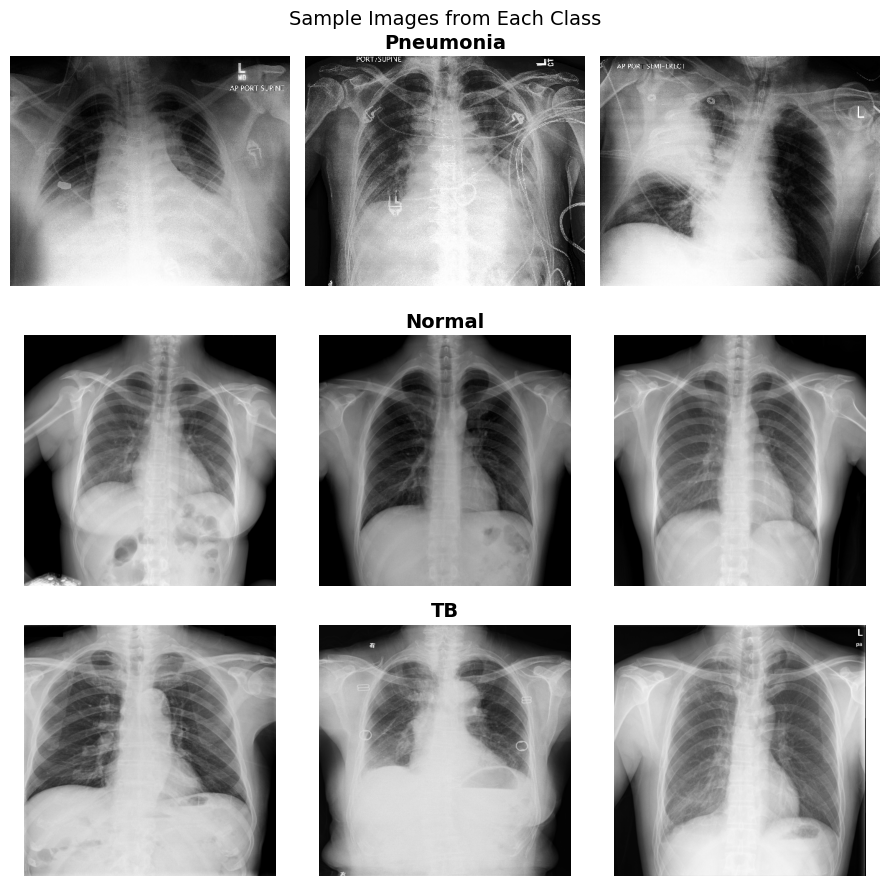

In [28]:
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

def show_sample_images(chexpert_df, tbx11k_df, n_per_class=3):
    """
    Display sample images from each target class:
    - Pneumonia (from CheXpert)
    - Normal (from TBX11K)
    - TB (from TBX11K)

    Parameters
    ----------
    chexpert_df : pd.DataFrame
        CheXpert labels DataFrame with 'Path' and 'Class'.
    tbx11k_df : pd.DataFrame
        TBX11K labels DataFrame with 'Path' and 'Class'.
    n_per_class : int
        Number of images to display per class.
    """
    # Pick random samples per class (limit to available size)
    samples = {
        "Pneumonia": chexpert_df[chexpert_df["Class"] == "Pneumonia"].sample(
            min(len(chexpert_df[chexpert_df["Class"] == "Pneumonia"]), n_per_class)
        ),
        "Normal": tbx11k_df[tbx11k_df["Class"] == "Normal"].sample(
            min(len(tbx11k_df[tbx11k_df["Class"] == "Normal"]), n_per_class)
        ),
        "TB": tbx11k_df[tbx11k_df["Class"] == "TB"].sample(
            min(len(tbx11k_df[tbx11k_df["Class"] == "TB"]), n_per_class)
        ),
    }

    # Create grid of subplots. Add 3 images to each class for clear comparison.
    fig, axes = plt.subplots(len(samples), n_per_class, figsize=(n_per_class * 3, len(samples) * 3))

    for row, (cls, df) in enumerate(samples.items()):
        for col, (_, rec) in enumerate(df.iterrows()):
            if cls == "Pneumonia":
                # Prepend dataset root because Path is relative
                img_path = CHEXPERT_PATH / rec["Path"]
            else:  # Normal or TB from TBX11K
                img_path = TBX11K_PATH / "imgs" / rec["Path"]

            # Open and plot image.
            img = Image.open(img_path)
            axes[row, col].imshow(img, cmap="gray" if img.mode == "L" else None)
            axes[row, col].axis("off")
            if col == n_per_class // 2:
                axes[row, col].set_title(cls, fontsize=14, fontweight="bold")

    # Add title to the plot.
    plt.suptitle("Sample Images from Each Class", fontsize=14)
    plt.tight_layout()
    plt.show()

# Display 3 random samples per class (Pneumonia, Normal, and TB).
show_sample_images(chexpert_labels, tbx11k_df, n_per_class=3)